# Análisis descriptivo y calidad de datos — Retail

**Universidad EAFIT • Fundamentos en Ciencia de Datos**

Este notebook adapta la estructura sencilla del cuaderno base de equinos al conjunto de datos de
ventas retail. Se usan:

- `retail_ventas_LIMPIO.csv` para la **Parte 1** y la interpretación final.
- `retail_ventas_CONTAMINADO.csv` para la **Parte 2**, sin utilizar el archivo limpio para reemplazar
  valores durante la limpieza.
- `reseñas_clientes.json` para la Tarea 1 (recolección multi-fuente): se integra como fuente
  semi-estructurada y se cruza por `store_id` con las ventas.

> **Declaración de uso de IA:** se utilizó IA generativa para apoyar la organización del notebook,
> la escritura inicial del código y la redacción. Los resultados fueron ejecutados y contrastados
> con las reglas del diccionario de variables. La interpretación y la decisión final deben ser
> revisadas y defendidas por el equipo.

## 0. Configuración inicial y carga de datos

In [43]:
from pathlib import Path
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Busca los archivos tanto en la carpeta actual como en la carpeta superior.
def buscar_archivo(nombre):
    candidatos = [
        Path.cwd() / "data" / "raw" / nombre,
        Path.cwd().parent / "data" / "raw" / nombre,
        Path.cwd() / ".." / "data" / "raw" / nombre,
    ]
    for ruta in candidatos:
        ruta = ruta.resolve()
        if ruta.exists():
            return ruta
    raise FileNotFoundError(f"No se encontró {nombre}")


ruta_limpio = buscar_archivo("retail_ventas_LIMPIO.csv")
ruta_contaminado = buscar_archivo("retail_ventas_CONTAMINADO.csv")

# Carpeta raíz del proyecto: .../data/raw/archivo.csv -> sube tres niveles.
raiz_proyecto = ruta_contaminado.parents[2]
carpeta_resultados = raiz_proyecto / "results"
carpeta_figuras = carpeta_resultados / "figuras"
carpeta_resultados.mkdir(parents=True, exist_ok=True)
carpeta_figuras.mkdir(parents=True, exist_ok=True)

df_limpio = pd.read_csv(ruta_limpio)
df_contaminado = pd.read_csv(ruta_contaminado)

print("LIMPIO:", df_limpio.shape)
print("CONTAMINADO:", df_contaminado.shape)

df_limpio.info()
df_limpio.head()

LIMPIO: (420, 11)
CONTAMINADO: (430, 11)
<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transaction_id   420 non-null    str    
 1   store_id         420 non-null    str    
 2   comuna           420 non-null    str    
 3   date             420 non-null    str    
 4   category         420 non-null    str    
 5   units_sold       420 non-null    int64  
 6   unit_price       420 non-null    float64
 7   payment_method   420 non-null    str    
 8   customer_rating  420 non-null    int64  
 9   store_lat        420 non-null    float64
 10  store_lon        420 non-null    float64
dtypes: float64(3), int64(2), str(6)
memory usage: 52.3 KB


,transaction_id,store_id,comuna,date,category,units_sold,unit_price,payment_method,customer_rating,store_lat,store_lon
0,T00001,S02,Laureles,2025-05-09,Bebidas,2,5100.0,App,5,6.24625,-75.58917
1,T00002,S02,Laureles,2025-06-03,Pasteles,4,8900.0,App,3,6.24605,-75.58977
2,T00003,S07,Aranjuez,2025-05-31,Snacks,1,3300.0,Tarjeta,4,6.27391,-75.55584
3,T00004,S04,Robledo,2025-06-07,Pan,3,3200.0,Efectivo,5,6.27054,-75.59354
4,T00005,S02,Laureles,2025-01-26,Bebidas,5,2100.0,Tarjeta,3,6.24270,-75.58825


In [44]:
# Estructura y tipos detectados por pandas
df_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transaction_id   420 non-null    str    
 1   store_id         420 non-null    str    
 2   comuna           420 non-null    str    
 3   date             420 non-null    str    
 4   category         420 non-null    str    
 5   units_sold       420 non-null    int64  
 6   unit_price       420 non-null    float64
 7   payment_method   420 non-null    str    
 8   customer_rating  420 non-null    int64  
 9   store_lat        420 non-null    float64
 10  store_lon        420 non-null    float64
dtypes: float64(3), int64(2), str(6)
memory usage: 52.3 KB


## Tarea 1 — Recolección de datos multi-fuente

La guía exige cargar las tres fuentes suministradas, no solo los dos archivos tabulares. Antes de
limpiar nada hay que registrar qué formato trae cada variable y si viene de una fuente
estructurada (CSV) o semi-estructurada (JSON).

In [ ]:
ruta_resenas = buscar_archivo("reseñas_clientes.json")
with open(ruta_resenas, encoding="utf-8") as archivo:
    resenas_json = json.load(archivo)

df_resenas = pd.json_normalize(resenas_json)

print("RESEÑAS:", df_resenas.shape)
df_resenas.info()
df_resenas.head()

**Decisión — aplanado del JSON.** `pd.json_normalize` no generó columnas con puntos ni listas
anidadas: cada reseña ya es un registro plano con seis campos (`review_id`, `store_id`, `date`,
`rating`, `text`, `sentiment`). Es un hallazgo en sí mismo, no un paso trivial: la guía advierte
sobre aplanar estructuras anidadas, pero en este archivo no existía esa anidación, así que no hay
que inventar una decisión de aplanado que el dato no exige.

---
## Parte 1 — Análisis estadístico general

### 1.1 — Taxonomía

Se clasifican cinco variables según el significado del dato, no solamente según el tipo que muestra
Python.

In [45]:
taxonomia = pd.DataFrame({
    "Variable": ["store_id", "category", "customer_rating", "units_sold", "unit_price"],
    "Clasificación": ["Nominal", "Nominal", "Ordinal", "Discreta", "Continua"],
    "Medida central válida": ["Moda", "Moda", "Mediana o moda", "Media, mediana o moda", "Media o mediana"],
    "Justificación": [
        "Es una etiqueta de tienda sin orden; promediar sus códigos no tiene significado.",
        "Son nombres de productos sin jerarquía; la categoría más frecuente se resume con la moda.",
        "Los valores 1 a 5 tienen orden, pero no garantizan distancias iguales; se usa mediana o moda.",
        "Cuenta unidades enteras; admite media, mediana y moda según la forma de la distribución.",
        "Es una magnitud monetaria con diferencias interpretables; admite media o mediana según el sesgo."
    ]
})
taxonomia

,Variable,Clasificación,Medida central válida,Justificación
0,store_id,Nominal,Moda,Es una etiqueta de tienda sin orden; promediar...
1,category,Nominal,Moda,Son nombres de productos sin jerarquía; la cat...
2,customer_rating,Ordinal,Mediana o moda,"Los valores 1 a 5 tienen orden, pero no garant..."
3,units_sold,Discreta,"Media, mediana o moda","Cuenta unidades enteras; admite media, mediana..."
4,unit_price,Continua,Media o mediana,Es una magnitud monetaria con diferencias inte...


**Respuesta 1.1.** `store_id` y `category` son nominales; solamente la moda representa un centro
válido. `customer_rating` es ordinal: sabemos que 5 es mejor que 4, pero no que el salto de 1 a 2
sea idéntico al salto de 4 a 5, por lo que se prefieren mediana o moda. `units_sold` es un conteo
discreto y `unit_price` es continuo; en ambas se puede usar media o mediana, eligiendo según la
forma de la distribución y la presencia de valores extremos.

### 1.2 — Medidas de tendencia central y dispersión

In [46]:
# Variable ordinal: customer_rating
# Variable continua: unit_price
resumen_12 = pd.DataFrame({
    "Mediana": [
        df_limpio["customer_rating"].median(),
        df_limpio["unit_price"].median()
    ],
    "Moda": [
        df_limpio["customer_rating"].mode().iloc[0],
        df_limpio["unit_price"].mode().iloc[0]
    ],
    "Media (solo referencia)": [
        df_limpio["customer_rating"].mean(),
        df_limpio["unit_price"].mean()
    ],
    "Desviación estándar": [
        np.nan,
        df_limpio["unit_price"].std()
    ],
    "IQR": [
        df_limpio["customer_rating"].quantile(.75) - df_limpio["customer_rating"].quantile(.25),
        df_limpio["unit_price"].quantile(.75) - df_limpio["unit_price"].quantile(.25)
    ],
    "Asimetría": [
        np.nan,
        df_limpio["unit_price"].skew()
    ]
}, index=["customer_rating (ordinal)", "unit_price (continua)"])

resumen_12.round(2)

,Mediana,Moda,Media (solo referencia),Desviación estándar,IQR,Asimetría
customer_rating (ordinal),4.0,4.0,3.89,NaN,2.0,NaN
unit_price (continua),3300.0,3300.0,3620.24,1755.88,2000.0,1.12


**a) Tendencia central.** Para `customer_rating` se usa la **mediana**, que es 4, y puede
complementarse con la moda, también 4. No se toma la media (3,89) como medida principal porque la
escala es ordinal y no demuestra intervalos iguales. Para `unit_price` se prefiere la **mediana de
3.300 COP**, porque su asimetría positiva (1,12) indica que los precios altos elevan la media
(3.620 COP).

**b) Dispersión.** Para el precio se reporta principalmente el **IQR de 2.000 COP**: la mitad central
de los precios ocupa un intervalo de esa amplitud. Como complemento, la desviación estándar es
1.755,88 COP; su tamaño muestra que el portafolio mezcla productos de precios bastante distintos,
lo que afecta la planeación de ingresos e inventario.

**c) IQR frente a desviación estándar.** El IQR es más informativo cuando hay sesgo, productos
premium o errores de digitación que generan precios extremos, porque usa el 50 % central y no se
deforma tanto como la desviación estándar.

### 1.3 — Variable cualitativa: categoría

In [47]:
frecuencia_categoria = pd.DataFrame({
    "Frecuencia": df_limpio["category"].value_counts(),
    "Proporción (%)": df_limpio["category"].value_counts(normalize=True).mul(100).round(2)
})
frecuencia_categoria

,Frecuencia,Proporción (%)
category,,
Snacks,116,27.62
Pan,109,25.95
Bebidas,104,24.76
Pasteles,91,21.67


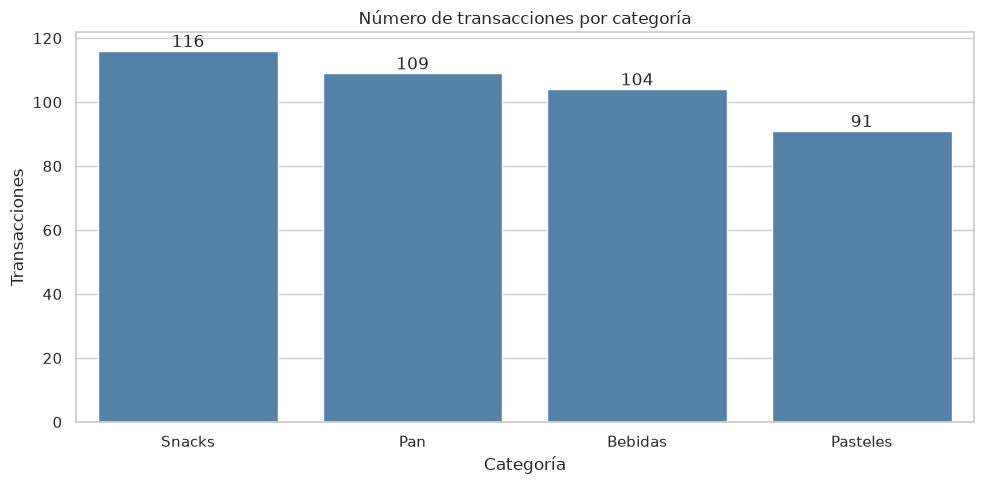

In [48]:
orden = frecuencia_categoria.index
ax = sns.countplot(data=df_limpio, x="category", order=orden, color="steelblue")
ax.set(title="Número de transacciones por categoría", xlabel="Categoría", ylabel="Transacciones")
for contenedor in ax.containers:
    ax.bar_label(contenedor)
plt.tight_layout()
plt.savefig(carpeta_figuras / "transacciones_por_categoria.jpg", dpi=150, bbox_inches="tight")
plt.show()

**Conclusión 1.3.** La tabla de frecuencias y el gráfico de barras muestran que `Snacks` tiene más
transacciones (116; 27,62 %) y `Pasteles` menos (91; 21,67 %). Este resumen ayuda a decidir qué
categorías necesitan mayor frecuencia de reabastecimiento, aunque debe complementarse con unidades
vendidas y valor monetario.

### 1.4 — Forma de la distribución y valores atípicos

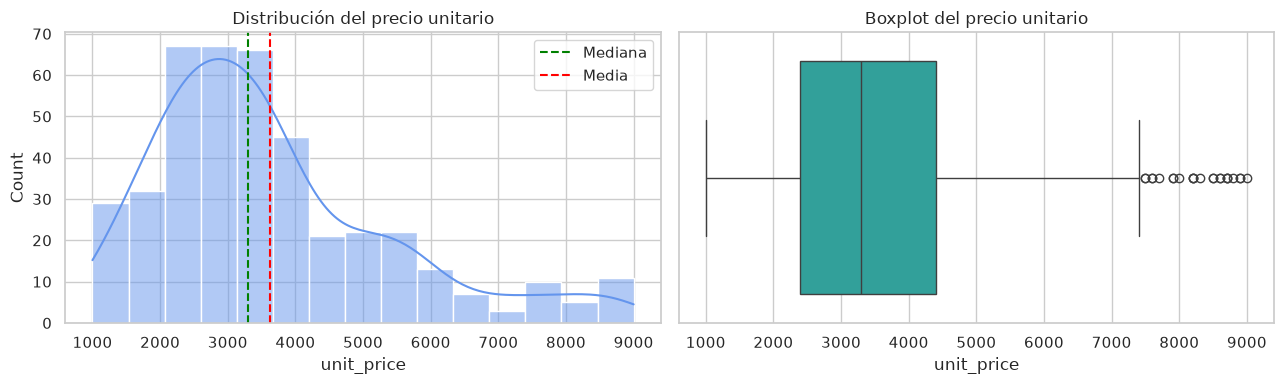

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_limpio["unit_price"], bins=15, kde=True, ax=axes[0], color="cornflowerblue")
axes[0].axvline(df_limpio["unit_price"].median(), color="green", linestyle="--", label="Mediana")
axes[0].axvline(df_limpio["unit_price"].mean(), color="red", linestyle="--", label="Media")
axes[0].set_title("Distribución del precio unitario")
axes[0].legend()
sns.boxplot(x=df_limpio["unit_price"], ax=axes[1], color="lightseagreen")
axes[1].set_title("Boxplot del precio unitario")
plt.tight_layout()
plt.savefig(carpeta_figuras / "distribucion_precio_unitario.jpg", dpi=150, bbox_inches="tight")
plt.show()

**Respuesta 1.4.** Se observa una distribución sesgada a la derecha: la mayoría de productos tiene
precios bajos o medios y algunos pasteles alcanzan precios más altos. Un valor alto puede ser
**atípico pero real** si coincide con el catálogo, la categoría y otras ventas similares. Se trata
como **error de captura** si rompe el rango comercial y el patrón sugiere un error sistemático; por
ejemplo, 540.000 COP cuando los productos comparables cuestan cerca de 5.400 COP.

### 1.5 — ¿Por qué la misma media puede exigir decisiones distintas?

In [50]:
# Ejemplo pequeño con la misma media, pero dispersión diferente
escenario_estable = pd.Series([3400, 3500, 3600, 3700, 3800])
escenario_variable = pd.Series([1000, 2000, 3600, 5200, 6200])

pd.DataFrame({
    "Media": [escenario_estable.mean(), escenario_variable.mean()],
    "Desviación estándar": [escenario_estable.std(), escenario_variable.std()],
    "Mínimo": [escenario_estable.min(), escenario_variable.min()],
    "Máximo": [escenario_estable.max(), escenario_variable.max()]
}, index=["Precios estables", "Precios variables"]).round(2)

,Media,Desviación estándar,Mínimo,Máximo
Precios estables,3600.0,158.11,3400,3800
Precios variables,3600.0,2158.70,1000,6200


**Respuesta 1.5.** Los dos escenarios tienen un precio medio de 3.600 COP, pero el segundo mezcla
precios muy bajos y muy altos. El primero permite una política de inventario uniforme; el segundo
exige segmentar por producto y controlar por separado los artículos costosos. La media no muestra
por sí sola la dispersión ni el riesgo.

---
## Parte 2 — Diagnóstico y transformación del archivo contaminado

Primero se diagnostica; todavía no se corrigen los datos.

In [51]:
diagnostico_basico = pd.DataFrame({
    "Nulos": df_contaminado.isna().sum(),
    "Tipo en pandas": df_contaminado.dtypes.astype(str)
})

diagnostico_basico["metodo_deteccion"] = ""

diagnostico_basico.loc[:, "metodo_deteccion"] = "df.isnull().sum()"
diagnostico_basico.loc["transaction_id", "metodo_deteccion"] = "df['transaction_id'].duplicated().sum()"
diagnostico_basico.loc["category", "metodo_deteccion"] = "df['category'].unique()"
diagnostico_basico.loc["date", "metodo_deteccion"] = "df['date'].sample(15)"
diagnostico_basico.loc["units_sold", "metodo_deteccion"] = "df['units_sold'].describe()"

diagnostico_basico

,Nulos,Tipo en pandas,metodo_deteccion
transaction_id,0,str,df['transaction_id'].duplicated().sum()
store_id,0,str,df.isnull().sum()
comuna,0,str,df.isnull().sum()
date,10,str,df['date'].sample(15)
category,0,str,df['category'].unique()
units_sold,21,float64,df['units_sold'].describe()
unit_price,12,float64,df.isnull().sum()
payment_method,0,str,df.isnull().sum()
customer_rating,64,float64,df.isnull().sum()
store_lat,0,float64,df.isnull().sum()


In [52]:
print("Duplicados exactos adicionales:", df_contaminado.duplicated().sum())
print("IDs de transacción repetidos:", df_contaminado["transaction_id"].duplicated().sum())
print("\nEtiquetas originales de category:")
print(sorted(df_contaminado["category"].unique()))

Duplicados exactos adicionales: 1
IDs de transacción repetidos: 10

Etiquetas originales de category:
[' Pan', ' Pasteles', 'BEBIDAS ', 'Bebida', 'Bebidas', 'PAN', 'PASTELES', 'Pan', 'Panes', 'Pastel', 'Pasteles', 'SNACKS', 'Snacks', 'Snaks', 'bebidas', 'pan', 'pan ', 'pasteles', 'snack']


In [53]:
# Reglas sencillas para detectar rangos imposibles
unidades_invalidas = df_contaminado["units_sold"].notna() & (df_contaminado["units_sold"] <= 0)
ratings_invalidos = (
    df_contaminado["customer_rating"].notna()
    & ~df_contaminado["customer_rating"].between(1, 5)
)
precios_sospechosos = df_contaminado["unit_price"] >= 100_000
coordenadas_invalidas = ~(
    df_contaminado["store_lat"].between(6.1, 6.4)
    & df_contaminado["store_lon"].between(-75.7, -75.4)
)

pd.Series({
    "Unidades <= 0": unidades_invalidas.sum(),
    "Ratings fuera de 1 a 5": ratings_invalidos.sum(),
    "Precios >= 100.000 COP": precios_sospechosos.sum(),
    "Coordenadas fuera del rango": coordenadas_invalidas.sum()
}, name="Cantidad")

Unidades <= 0                  8
Ratings fuera de 1 a 5         6
Precios >= 100.000 COP         5
Coordenadas fuera del rango    6
Name: Cantidad, dtype: int64

In [54]:
# Conteo de formatos visibles de fecha
def formato_fecha(valor):
    if pd.isna(valor):
        return "Nulo"
    valor = str(valor)
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", valor):
        return "YYYY-MM-DD"
    if re.fullmatch(r"\d{2}/\d{2}/\d{4}", valor):
        return "DD/MM/YYYY"
    if re.fullmatch(r"\d{2}-\d{2}-\d{4}", valor):
        return "MM-DD-YYYY"
    if re.search(r"[A-Za-z]", valor):
        return "Mes en texto"
    return "Otro"

df_contaminado["date"].map(formato_fecha).value_counts()

date
YYYY-MM-DD      325
DD/MM/YYYY       39
MM-DD-YYYY       28
Mes en texto     28
Nulo             10
Name: count, dtype: int64

### 2.1 — Diagnóstico de calidad

| Problema detectado | Columnas | Detección con pandas | Riesgo para el negocio |
|---|---|---|---|
| Faltantes: 10 fechas, 21 unidades, 12 precios y 64 ratings | `date`, `units_sold`, `unit_price`, `customer_rating` | `isna().sum()` | Subestima ventas, ingresos o insatisfacción. |
| 1 duplicado exacto adicional y 10 IDs repetidos | `transaction_id` y demás columnas | `duplicated()` y `duplicated(subset=...)` | Infla rotación e ingresos. |
| 19 textos para 4 categorías reales | `category` | `unique()` / `value_counts()` | Fragmenta una categoría en grupos falsos. |
| Fechas ISO, con `/`, con `-`, texto y nulos | `date` | patrones de texto y `to_datetime(..., errors="coerce")` | Asigna ventas al día o mes equivocado. |
| 8 cantidades negativas y 6 ratings fuera de 1–5 | `units_sold`, `customer_rating` | `between()` y comparaciones | Distorsiona demanda y satisfacción. |
| 5 precios con dos ceros adicionales | `unit_price` | regla comercial y revisión por categoría | Infla el ingreso y la dispersión. |
| 6 coordenadas en cero o fuera de Medellín | `store_lat`, `store_lon` | `between()` para latitud y longitud | Ubica tiendas en zonas incorrectas. |

El diagnóstico cubre completitud, unicidad y consistencia antes de modificar el archivo.

### 2.2 — Conversión de fechas

In [55]:
# El archivo mezcla DD/MM/YYYY con MM-DD-YYYY; por eso se separan ambos casos.
fechas_texto = df_contaminado["date"].astype("string")
usa_slash = fechas_texto.str.fullmatch(r"\d{2}/\d{2}/\d{4}", na=False)

fechas_convertidas = pd.Series(pd.NaT, index=df_contaminado.index, dtype="datetime64[ns]")
fechas_convertidas.loc[usa_slash] = pd.to_datetime(
    fechas_texto.loc[usa_slash], format="%d/%m/%Y", errors="coerce"
)
fechas_convertidas.loc[~usa_slash] = pd.to_datetime(
    fechas_texto.loc[~usa_slash], format="mixed", dayfirst=False, errors="coerce"
)

print("Fechas no convertibles o faltantes:", fechas_convertidas.isna().sum())
print("Rango convertido:", fechas_convertidas.min().date(), "a", fechas_convertidas.max().date())

Fechas no convertibles o faltantes: 10
Rango convertido: 2025-01-01 a 2025-06-29


**Decisión 2.2.** `errors="coerce"` evita detener el proceso y convierte lo no interpretable en
`NaT`. Si el 8 % no se convierte, se deja como nulo explícito y esas filas se excluyen solamente de
análisis temporales; no se inventa una fecha porque hacerlo puede mover ventas a un mes equivocado.
La fila puede conservarse para análisis por tienda o categoría.

### 2.3 — Estandarización de la categoría

In [56]:
mapa_categoria = {
    "bebida": "Bebidas",
    "bebidas": "Bebidas",
    "pan": "Pan",
    "panes": "Pan",
    "pastel": "Pasteles",
    "pasteles": "Pasteles",
    "snack": "Snacks",
    "snacks": "Snacks",
    "snaks": "Snacks"
}

categoria_limpia = (
    df_contaminado["category"]
    .str.strip()
    .str.lower()
    .map(mapa_categoria)
)

pd.DataFrame({
    "Original": df_contaminado["category"],
    "Estandarizada": categoria_limpia
}).drop_duplicates().sort_values(["Estandarizada", "Original"])

,Original,Estandarizada
112,BEBIDAS,Bebidas
169,Bebida,Bebidas
7,Bebidas,Bebidas
54,bebidas,Bebidas
121,Pan,Pan
178,PAN,Pan
3,Pan,Pan
259,Panes,Pan
388,pan,Pan
29,pan,Pan


**Decisión 2.3.** Se eliminan espacios, se pasa a minúscula y se aplica un diccionario. Se consideran
iguales únicamente las variantes claras de número, mayúsculas o error ortográfico (`Snaks`).
No se usa similitud automática sin revisión, porque podría unir productos realmente distintos.

### 2.4 — Georreferenciación

In [57]:
# Rango operativo aproximado usado para Medellín y las tiendas del archivo
geo_valida = (
    df_contaminado["store_lat"].between(6.1, 6.4)
    & df_contaminado["store_lon"].between(-75.7, -75.4)
)

df_contaminado.loc[
    ~geo_valida,
    ["transaction_id", "store_id", "store_lat", "store_lon"]
]

,transaction_id,store_id,store_lat,store_lon
125,T00011,S05,0.00000,0.00000
146,T00393,S06,0.00000,0.00000
304,T00338,S04,0.00000,0.00000
374,T00076,S01,46.20987,-75.56624
399,T00362,S02,46.24496,-75.58880
413,T00112,S04,46.27285,-75.59422


**Decisión 2.4.** Se valida latitud entre 6,1 y 6,4 y longitud entre −75,7 y −75,4. Una inversión
solo se corregiría automáticamente si al intercambiar ambos valores la pareja entra al rango y
coincide con la ubicación usual de la misma tienda. Los ceros o valores como latitud 46 se marcan
inválidos y se reemplazan con la mediana de coordenadas válidas de su `store_id`. Un intercambio
automático sin esa prueba puede fabricar una ubicación plausible pero falsa.

### 2.5 — Imputación y valores imposibles

In [58]:
# units_sold es un conteo: debe ser entero y mayor que cero.
unidades_validas = (
    df_contaminado["units_sold"].isna()
    | (
        (df_contaminado["units_sold"] > 0)
        & (df_contaminado["units_sold"] % 1 == 0)
    )
)

print("Filas con unidades imposibles:", (~unidades_validas).sum())
df_contaminado.loc[~unidades_validas, ["transaction_id", "units_sold"]]

Filas con unidades imposibles: 8


,transaction_id,units_sold
2,T00419,-2.0
111,T00368,-3.0
120,T00088,-4.0
123,T00322,-6.0
125,T00011,-4.0
188,T00304,-2.0
190,T00139,-3.0
319,T00267,-5.0


**Decisión 2.5.** Una venta debe contener un número entero mayor que cero. Los negativos no se
convierten con valor absoluto porque no sabemos si el error está en el signo o también en la
magnitud. Se pasan a nulo y se imputan con la mediana de unidades de su categoría. Esta estrategia
mantiene la fila, pero reduce artificialmente la variabilidad y puede acercar demasiado la demanda
de cada categoría a su valor típico.

### 2.6 — Duplicados y llave de negocio

In [59]:
duplicados_id = df_contaminado[
    df_contaminado.duplicated(subset="transaction_id", keep=False)
].sort_values("transaction_id")

duplicados_id[[
    "transaction_id", "date", "category", "units_sold",
    "unit_price", "customer_rating"
]]

,transaction_id,date,category,units_sold,unit_price,customer_rating
25,T00059,2025-01-31,Snacks,5.0,2100.0,5.0
377,T00059,2025-01-31,Snacks,5.0,2100.0,5.0
382,T00074,NaN,Pan,3.0,2200.0,3.0
402,T00074,2025-01-25,Pan,3.0,2200.0,3.0
23,T00081,01/02/2025,Bebidas,4.0,5800.0,4.0
167,T00081,2025-02-01,Bebidas,4.0,5800.0,4.0
77,T00103,2025-03-18,Pan,2.0,1700.0,3.0
82,T00103,18/03/2025,Pan,2.0,1700.0,3.0
95,T00120,2025-06-15,Bebidas,5.0,4700.0,2.0
226,T00120,2025-06-15,Bebidas,5.0,4700.0,NaN


**Decisión 2.6.** 

Una posible **llave de negocio** para detectar duplicados reales es la combinación de **`store_id + date + category + unit_price`**, ya que estos atributos describen el evento de venta mejor que **`transaction_id`**. Este último es un identificador técnico generado por el sistema y puede cambiar si una transacción se registra nuevamente debido a un error, un reintento o un problema en el proceso de captura. En ese caso, dos registros con diferentes `transaction_id` podrían corresponder a la misma venta.

Un **duplicado exacto de fila** ocurre cuando todas las columnas tienen los mismos valores, lo que normalmente indica un problema de carga o almacenamiento de datos. En cambio, un **duplicado de evento de negocio** ocurre cuando la misma venta se registra más de una vez, aunque algunos campos (como `transaction_id`) sean diferentes. Por ello, para identificar duplicados reales es necesario comparar los atributos que describen el evento de negocio y no depender únicamente de un identificador técnico.

---
## 3. Limpieza reproducible

El siguiente bloque reúne las decisiones anteriores. El archivo limpio de referencia no se usa para
rellenar valores; solamente se contrasta al final.

In [60]:
df = df_contaminado.copy()

# 1. Categorías
df["category"] = df["category"].str.strip().str.lower().map(mapa_categoria)

# 2. Fechas
texto = df["date"].astype("string")
slash = texto.str.fullmatch(r"\d{2}/\d{2}/\d{4}", na=False)
df["date"] = pd.NaT
df.loc[slash, "date"] = pd.to_datetime(texto.loc[slash], format="%d/%m/%Y", errors="coerce")
df.loc[~slash, "date"] = pd.to_datetime(
    texto.loc[~slash], format="mixed", dayfirst=False, errors="coerce"
)
df["date"] = pd.to_datetime(df["date"])

# 3. Valores imposibles
df.loc[df["units_sold"] <= 0, "units_sold"] = np.nan
df.loc[~df["customer_rating"].between(1, 5), "customer_rating"] = np.nan

# Los cinco precios >= 100.000 tienen dos ceros adicionales.
# Solo se corrigen si dividir por 100 produce un valor dentro del rango comercial 1.000–9.000.
precio_corregido = df["unit_price"] / 100
error_dos_ceros = (df["unit_price"] >= 100_000) & precio_corregido.between(1_000, 9_000)
df.loc[error_dos_ceros, "unit_price"] = precio_corregido.loc[error_dos_ceros]

# 4. Imputación de variables necesarias para estimar demanda e ingreso
df["units_sold"] = df["units_sold"].fillna(
    df.groupby("category")["units_sold"].transform("median")
).round().astype("Int64")
df["unit_price"] = df["unit_price"].fillna(
    df.groupby("category")["unit_price"].transform("median")
)

# El rating faltante se conserva: no se fabrica satisfacción.
df["customer_rating"] = df["customer_rating"].astype("Int64")

# 5. Coordenadas: usar la ubicación típica de la misma tienda
geo_ok = (
    df["store_lat"].between(6.1, 6.4)
    & df["store_lon"].between(-75.7, -75.4)
)
medianas_geo = df.loc[geo_ok].groupby("store_id")[["store_lat", "store_lon"]].median()
for columna in ["store_lat", "store_lon"]:
    df.loc[~geo_ok, columna] = df.loc[~geo_ok, "store_id"].map(medianas_geo[columna])

# 6. Duplicados de negocio: conservar la versión más completa
df["_completitud"] = df.notna().sum(axis=1)
df = (
    df.sort_values("_completitud", ascending=False)
      .drop_duplicates(subset="transaction_id", keep="first")
      .drop(columns="_completitud")
      .sort_values("transaction_id")
      .reset_index(drop=True)
)

print("Dimensiones finales:", df.shape)
display(df.head())

Dimensiones finales: (420, 11)


,transaction_id,store_id,comuna,date,category,units_sold,unit_price,payment_method,customer_rating,store_lat,store_lon
0,T00001,S02,Laureles,2025-05-09,Bebidas,2,5100.0,App,5,6.24625,-75.58917
1,T00002,S02,Laureles,2025-06-03,Pasteles,4,8900.0,App,3,6.24605,-75.58977
2,T00003,S07,Aranjuez,2025-05-31,Snacks,1,3300.0,Tarjeta,4,6.27391,-75.55584
3,T00004,S04,Robledo,2025-06-07,Pan,3,3200.0,Efectivo,5,6.27054,-75.59354
4,T00005,S02,Laureles,2025-01-26,Bebidas,5,2100.0,Tarjeta,3,6.24270,-75.58825


In [61]:
# Verificación de reglas, sin comparar todavía valores celda a celda con el archivo limpio
verificacion = pd.Series({
    "IDs duplicados": df["transaction_id"].duplicated().sum(),
    "Categorías no reconocidas": df["category"].isna().sum(),
    "Unidades nulas o <= 0": (df["units_sold"].isna() | (df["units_sold"] <= 0)).sum(),
    "Precios nulos o <= 0": (df["unit_price"].isna() | (df["unit_price"] <= 0)).sum(),
    "Ratings fuera de 1 a 5": (
        df["customer_rating"].notna() & ~df["customer_rating"].between(1, 5)
    ).sum(),
    "Coordenadas inválidas": (~(
        df["store_lat"].between(6.1, 6.4)
        & df["store_lon"].between(-75.7, -75.4)
    )).sum()
}, name="Cantidad")
verificacion

IDs duplicados               0
Categorías no reconocidas    0
Unidades nulas o <= 0        0
Precios nulos o <= 0         0
Ratings fuera de 1 a 5       0
Coordenadas inválidas        0
Name: Cantidad, dtype: int64

In [62]:
# Exportación del resultado procesado
ruta_salida = carpeta_resultados / "retail_ventas_PROCESADO.csv"
df.to_csv(ruta_salida, index=False, date_format="%Y-%m-%d")
print("Archivo guardado en:", ruta_salida)

Archivo guardado en: /home/juan-jose/challenge1-retail-db/results/retail_ventas_PROCESADO.csv


In [63]:
# Validación final contra la referencia: se compara, no se usa para sobrescribir.
print("Filas procesadas / referencia:", len(df), "/", len(df_limpio))
print("Mismas 4 categorías:",
      set(df["category"].dropna()) == set(df_limpio["category"]))
print("Mismos identificadores:",
      set(df["transaction_id"]) == set(df_limpio["transaction_id"]))

Filas procesadas / referencia: 420 / 420
Mismas 4 categorías: True
Mismos identificadores: True


**Resultado de la limpieza.** Se recuperan 420 eventos únicos y las cuatro categorías esperadas.
Las fechas sin evidencia y los ratings faltantes permanecen nulos. Las imputaciones de unidades y
precios deben entenderse como estimaciones: permiten resumir demanda e ingreso, pero no recuperan
el valor original con certeza.

---
## Parte 3 — Interpretación y decisión para Retail

### Resumen por categoría

In [64]:
analisis = df_limpio.copy()
analisis["ingreso"] = analisis["units_sold"] * analisis["unit_price"]

resumen_categoria = analisis.groupby("category").agg(
    transacciones=("transaction_id", "count"),
    unidades_totales=("units_sold", "sum"),
    unidades_promedio=("units_sold", "mean"),
    precio_promedio=("unit_price", "mean"),
    rating_mediano=("customer_rating", "median"),
    ingreso_total=("ingreso", "sum")
).round(2).sort_values("unidades_promedio", ascending=False)

resumen_categoria

,transacciones,unidades_totales,unidades_promedio,precio_promedio,rating_mediano,ingreso_total
category,,,,,,
Pan,109,442,4.06,2642.20,4.0,1169700.0
Snacks,116,387,3.34,2496.55,4.0,995700.0
Bebidas,104,299,2.88,3964.42,4.0,1175500.0
Pasteles,91,238,2.62,5830.77,4.0,1388700.0


In [65]:
resumen_tienda = analisis.groupby(["store_id", "comuna"]).agg(
    transacciones=("transaction_id", "count"),
    rating_mediano=("customer_rating", "median"),
    rating_promedio_referencia=("customer_rating", "mean")
).round(2).sort_values("rating_promedio_referencia")

resumen_tienda

,,transacciones,rating_mediano,rating_promedio_referencia
store_id,comuna,,,
S07,Aranjuez,40,4.0,3.72
S05,Envigado,55,4.0,3.73
S01,El Poblado,51,4.0,3.86
S06,Buenos Aires,54,4.0,3.87
S02,Laureles,48,4.0,3.92
S08,Castilla,70,4.0,3.97
S03,Belén,57,4.0,3.98
S04,Robledo,45,4.0,4.00


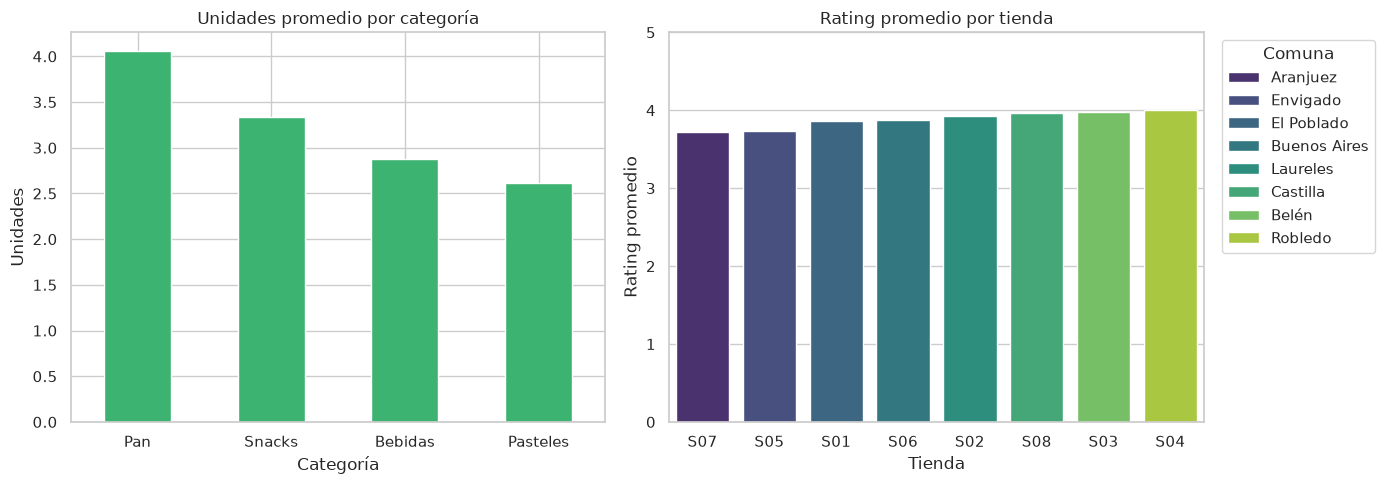

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumen_categoria["unidades_promedio"].plot(
    kind="bar", ax=axes[0], color="mediumseagreen"
)
axes[0].set(title="Unidades promedio por categoría", xlabel="Categoría", ylabel="Unidades")
axes[0].tick_params(axis="x", rotation=0)

orden_tiendas = resumen_tienda.reset_index()
sns.barplot(
    data=orden_tiendas,
    x="store_id",
    y="rating_promedio_referencia",
    hue="comuna",
    dodge=False,
    ax=axes[1],
    palette="viridis"
)
axes[1].set(title="Rating promedio por tienda", xlabel="Tienda", ylabel="Rating promedio")
axes[1].set_ylim(0, 5)
axes[1].legend(title="Comuna", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(carpeta_figuras / "resumen_categoria_tienda.jpg", dpi=150, bbox_inches="tight")
plt.show()

### 3.A — Decisión de inventario

**a)** `Pan` tiene la mayor rotación promedio (4,06 unidades por transacción) y un precio promedio
relativamente bajo (2.642 COP). Conviene asegurar su disponibilidad con reposiciones pequeñas y
frecuentes: quedarse corto pierde ventas recurrentes, mientras un exceso aumenta merma por ser un
producto perecedero. `Pasteles` genera el mayor ingreso observado, así que el presupuesto no debe
asignarse mirando únicamente unidades.

**b)** Las tiendas con menor calificación promedio son **S07–Aranjuez (3,72)** y
**S05–Envigado (3,73)**. La diferencia es mínima, por lo que ambas merecen diagnóstico. Una
hipótesis de negocio es que la alta demanda en horas pico produce filas, agotados o producto menos
fresco; debe validarse con horarios, inventario y comentarios de clientes, información no disponible
en estos CSV.

**c) Recomendación al gerente.** Priorizar un piloto de reposición frecuente de Pan en S07 y S05,
acompañado de una revisión operativa del servicio en horas pico. Proteger también el abastecimiento
de Pasteles por su mayor ingreso total. Medir durante cuatro semanas quiebres, merma y distribución
de ratings. No actuar arriesga pérdida de ventas y clientes; sobrerreaccionar puede elevar el
desperdicio.

---
## Decisión recomendada

1. **Pregunta de negocio:** ¿qué categoría y qué tienda presentan mayor riesgo de perder ventas o
   clientes por falta de inventario o servicio deficiente?
2. **Acción:** piloto de reposición frecuente de Pan y revisión operativa en S07 y S05, sin descuidar
   Pasteles por su aporte monetario.
3. **Falso positivo:** intervenir una tienda o aumentar inventario cuando no era necesario genera
   costo operativo, capital inmovilizado y merma.
4. **Falso negativo:** no intervenir donde sí existe el problema causa quiebres, ventas perdidas y
   deterioro de la experiencia del cliente.
5. **Limitación:** no hay costo, margen, inventario disponible, hora de la venta ni texto de reseñas.
   Por eso el precio no demuestra margen y el rating no explica por sí solo la causa del problema.